# 01 - Probability and Bayes' theorem

**Goal.** Build Bayes' theorem from the definition of conditional probability, use it
on a screening test where intuition fails badly, learn the odds form that makes
repeated updating easy, and write a small function that applies the theorem to any
finite set of hypotheses.

## 1. Events and the rules of probability

An **experiment** has a set of possible outcomes $\Omega$ (the sample space). An
**event** $A$ is a subset of $\Omega$. Probability assigns each event a number with
three properties [1]:
$$ P(A)\ge 0, \qquad P(\Omega)=1, \qquad P(A\cup B)=P(A)+P(B) \text{ if } A\cap B=\varnothing. $$
Everything else follows. Two consequences we use constantly:

- **Complement:** $P(A^c) = 1-P(A)$, since $A$ and $A^c$ are disjoint and together make $\Omega$.
- **Union:** $P(A\cup B) = P(A)+P(B)-P(A\cap B)$. Adding $P(A)$ and $P(B)$ counts the
  overlap twice, so we subtract it once.

## 2. Conditional probability and independence

The probability of $A$ **given** that $B$ has happened is
$$ P(A\mid B) = \frac{P(A\cap B)}{P(B)}, \qquad P(B)>0. $$
Conditioning on $B$ shrinks the sample space to $B$ and rescales so that it has
probability one. Rearranged, it gives the **multiplication rule**
$$ P(A\cap B) = P(A\mid B)\,P(B) = P(B\mid A)\,P(A). $$

$A$ and $B$ are **independent** when $P(A\cap B) = P(A)P(B)$, equivalently when
$P(A\mid B) = P(A)$: learning $B$ tells you nothing about $A$.

**Example.** Draw one card from a shuffled deck. Let $A$ = "the card is a king" and
$B$ = "the card is a heart". Then $P(A\cap B) = 1/52$, $P(A)P(B) = (4/52)(13/52) =
1/52$, so rank and suit are independent. But if $C$ = "the card is a face card"
(jack, queen or king), $P(A\mid C) = 4/12 = 1/3 \ne 1/13 = P(A)$.

## 3. The law of total probability

Suppose events $H_1,\dots,H_m$ form a **partition**: exactly one of them happens.
Then any event $E$ splits into the disjoint pieces $E\cap H_i$, and
$$ P(E) = \sum_{i=1}^m P(E\cap H_i) = \sum_{i=1}^m P(E\mid H_i)\,P(H_i). $$
The probability of $E$ is a weighted average of its probability under each
hypothesis, weighted by how probable each hypothesis is.

## 4. Bayes' theorem

The multiplication rule can be written two ways, $P(H\mid E)P(E) = P(E\mid H)P(H)$.
Dividing by $P(E)$ and expanding $P(E)$ by total probability:
$$ \boxed{\;P(H_j\mid E) = \frac{P(E\mid H_j)\,P(H_j)}{\sum_{i=1}^m P(E\mid H_i)\,P(H_i)}\;} $$
Each piece has a name:

- $P(H_j)$ is the **prior** probability of hypothesis $j$, before the evidence.
- $P(E\mid H_j)$ is the **likelihood**: how well hypothesis $j$ predicted the evidence.
- $P(E)$ is the **evidence** (or marginal likelihood), the same for every $j$.
- $P(H_j\mid E)$ is the **posterior**.

Read it as: *the posterior is proportional to prior times likelihood*. A hypothesis
gains probability when it predicted the evidence better than the average hypothesis
did, and loses probability otherwise.

## 5. A screening test

A condition affects 1% of people. A screening test detects it in 95% of people who
have it (its **sensitivity**) and correctly gives a negative result for 90% of people
who do not (its **specificity**). A randomly chosen person tests positive. How likely
is it that they have the condition?

Let $D$ = "has the condition" and $+$ = "tests positive". Then
$$ P(D\mid +) = \frac{P(+\mid D)P(D)}{P(+\mid D)P(D) + P(+\mid D^c)P(D^c)}
   = \frac{0.95\times 0.01}{0.95\times 0.01 + 0.10\times 0.99} = \frac{0.0095}{0.1085} \approx 0.088. $$
Less than 9%, even though the test is "95% accurate". The reason is the **base
rate**: the condition is rare, so the false positives from the 99% of healthy people
far outnumber the true positives. Ignoring the base rate is one of the best
documented errors in human reasoning [4].

**Natural frequencies** make this obvious [5]. Out of 10,000 people, 100 have the
condition and 95 of them test positive. Of the 9,900 without it, 10%, that is 990,
also test positive. So of $95 + 990 = 1085$ positives, only 95 are real:
$95/1085 \approx 8.8\%$.

Let's check this by brute force: simulate a million people and count.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"
rng = np.random.default_rng(1)

prevalence, sensitivity, specificity = 0.01, 0.95, 0.90
N = 1_000_000
has_condition = rng.random(N) < prevalence
positive = np.where(has_condition, rng.random(N) < sensitivity, rng.random(N) > specificity)

exact = sensitivity * prevalence / (sensitivity * prevalence + (1 - specificity) * (1 - prevalence))
print(f"exact  P(D | +) = {exact:.4f}")
print(f"simulated       = {has_condition[positive].mean():.4f}  ({positive.sum():,} positives)")

exact  P(D | +) = 0.0876
simulated       = 0.0878  (108,576 positives)


## 6. Odds, likelihood ratios and repeated tests

Probabilities near 0 or 1 are awkward to update by hand. **Odds** are easier. The
odds of $H$ are $O(H) = P(H)/P(H^c)$. Writing Bayes' theorem for $H$ and for $H^c$
and dividing, the evidence $P(E)$ cancels:
$$ \underbrace{\frac{P(H\mid E)}{P(H^c\mid E)}}_{\text{posterior odds}}
   = \underbrace{\frac{P(E\mid H)}{P(E\mid H^c)}}_{\text{likelihood ratio}}
   \times \underbrace{\frac{P(H)}{P(H^c)}}_{\text{prior odds}}. $$
For the screening test the likelihood ratio of a positive result is
$0.95/0.10 = 9.5$. Prior odds $1/99$ become posterior odds $9.5/99 \approx 0.096$,
which is probability $0.096/1.096 \approx 0.088$, as before.

**Updating is repeatable.** Suppose the person takes a second, independent test and
it is positive too. Today's posterior is tomorrow's prior, so we multiply the odds by
$9.5$ again: $9.5^2/99 \approx 0.91$, a probability of about $0.48$. Two positives
move us from 1% to about 48%. Because multiplication is commutative, the order of the
evidence does not matter, and updating one test at a time gives exactly the same
answer as using both at once. (This relies on the tests being independent **given**
the person's true status. Chapter 04 proves the general version.)

In [2]:
def update_odds(p, likelihood_ratio):
    odds = p / (1 - p) * likelihood_ratio
    return odds / (1 + odds)

LR_pos = sensitivity / (1 - specificity)          # 9.5
LR_neg = (1 - sensitivity) / specificity          # a negative result: about 0.056

p = prevalence
for result in ["+", "+", "-"]:
    p = update_odds(p, LR_pos if result == "+" else LR_neg)
    print(f"after a {result} result: P(D) = {p:.4f}")

after a + result: P(D) = 0.0876
after a + result: P(D) = 0.4769
after a - result: P(D) = 0.0482


A third test that comes back negative pulls the probability back down to about 5%:
a negative result from a sensitive test is strong evidence against the condition.

## 7. More than two hypotheses

A factory has three machines. Machine A makes 50% of the parts, B makes 30% and C
makes 20%. Their defect rates are 1%, 2% and 5%. A part is found to be defective.
Which machine made it?

The priors are the production shares and the likelihoods are the defect rates:
$$ P(\text{defective}) = 0.5(0.01) + 0.3(0.02) + 0.2(0.05) = 0.005+0.006+0.010 = 0.021, $$
$$ P(A\mid \text{def}) = \tfrac{0.005}{0.021}\approx 0.24,\qquad
   P(B\mid \text{def}) = \tfrac{0.006}{0.021}\approx 0.29,\qquad
   P(C\mid \text{def}) = \tfrac{0.010}{0.021}\approx 0.48. $$
Machine C makes the fewest parts but is now the most likely source, because it is
much better at explaining the evidence.

The computation is always the same three steps (multiply, sum, divide), so it is
worth writing once. The function below is Bayes' theorem for any finite set of
hypotheses; we will reuse the idea with thousands of hypotheses in chapter 04.

posterior: A: 0.238, B: 0.286, C: 0.476


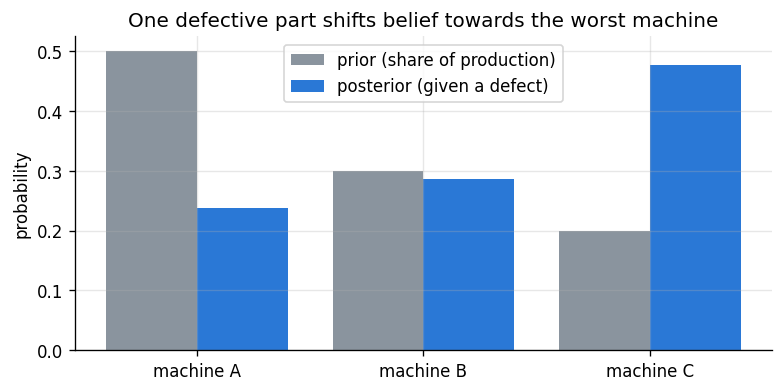

In [3]:
def bayes(prior, likelihood):
    """Posterior over a finite set of hypotheses: prior times likelihood, normalised."""
    unnorm = np.asarray(prior, float) * np.asarray(likelihood, float)
    return unnorm / unnorm.sum()

machines = ["A", "B", "C"]
prior = [0.5, 0.3, 0.2]
defect_rate = [0.01, 0.02, 0.05]
post = bayes(prior, defect_rate)
print("posterior:", ", ".join(f"{m}: {p:.3f}" for m, p in zip(machines, post)))

x = np.arange(3)
plt.bar(x - 0.2, prior, width=0.4, color=PRIOR, label="prior (share of production)")
plt.bar(x + 0.2, post, width=0.4, color=POST, label="posterior (given a defect)")
plt.xticks(x, [f"machine {m}" for m in machines]); plt.ylabel("probability")
plt.title("One defective part shifts belief towards the worst machine")
plt.legend(); plt.show()

## 8. Where this is going

Everything in this chapter had a finite list of hypotheses. In statistics the
"hypotheses" are usually the possible values of a continuous parameter, such as a
cure rate anywhere in $[0,1]$. The sum in the denominator then becomes an integral,
and probabilities become densities. Chapter 02 builds the vocabulary for that
(random variables and their distributions), and chapter 04 makes the jump.

### Exercises

1. Show that if $A$ and $B$ are independent then so are $A$ and $B^c$.
2. In the screening example, how high would prevalence need to be for a single
   positive test to give $P(D\mid +) \ge 0.5$? Solve it with the odds form, then
   check it with the simulation.
3. A second test has sensitivity 0.80 and specificity 0.99. Which is more
   informative after a first positive: a positive from this test or from another copy
   of the first test? Compare their likelihood ratios.
4. (Monty Hall.) A prize is behind one of three doors. You pick door 1. The host, who
   knows where the prize is and always opens an empty door you did not pick, opens
   door 3. Use `bayes` to find the probability that the prize is behind door 2. Be
   careful with the likelihood of the host opening door 3 under each hypothesis.
5. In the factory example, a second part from the same (unknown) machine is also
   defective. Update the posterior. Is updating twice with one defect the same as
   updating once with a likelihood equal to the defect rate squared? Why?

## References

1. A. N. Kolmogorov. *Foundations of the Theory of Probability.* Chelsea, 1950 (German original 1933).
2. T. Bayes. *An Essay towards solving a Problem in the Doctrine of Chances.* Philosophical Transactions of the Royal Society of London, 53:370-418, 1763. doi:10.1098/rstl.1763.0053
3. P.-S. Laplace. *Mémoire sur la probabilité des causes par les événements.* Mémoires de l'Académie royale des sciences de Paris, 6:621-656, 1774.
4. A. Tversky, D. Kahneman. *Judgment under Uncertainty: Heuristics and Biases.* Science, 185(4157):1124-1131, 1974. doi:10.1126/science.185.4157.1124
5. G. Gigerenzer, U. Hoffrage. *How to improve Bayesian reasoning without instruction: frequency formats.* Psychological Review, 102(4):684-704, 1995. doi:10.1037/0033-295X.102.4.684
6. J. Blitzstein, J. Hwang. *Introduction to Probability*, 2nd ed. CRC Press, 2019. (Chapter 2 on conditional probability.)